In [1]:
from math import pi, sqrt, gcd
from heapq import nlargest
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import DensityMatrix
import matplotlib.pyplot as plt

In [2]:
N = 15
x = 2
n_qubits = 5
candidates = list(range(2**n_qubits)) # 設定候選數字

In [3]:
marked = []

# 搜尋滿足 x^a mod N == 1 的 a 值
for a in candidates:
    if a == 0:
        continue
    if pow(x, a, N) == 1:
        marked.append(a)

print(f"符合條件的 a: {marked}")

符合條件的 a: [4, 8, 12, 16, 20, 24, 28]


# orcale

**多控制 Z gate（$MCZ$）**
對於 $n$ 個位元，$MCZ$ 對狀態 $|1\rangle^{\otimes n}$ 施加 $-1$ 相位，其矩陣是 $2^n \times 2^n$ 單位矩陣，只在最後一項變成 $-1$：

$MCZ = I - 2|1\cdots1\rangle\langle 1\cdots1|$

**多控制 Toffoli gate（$MCT$）**
這是一種多控制的 NOT gate，只有當所有控制 qubit 為 $|1\rangle$ 時，對目標位元套用 $X$ gate。

$MCT : |x_1 x_2 \cdots x_{n-1}, y\rangle \rightarrow |x_1 x_2 \cdots x_{n-1}, y \oplus (x_1 \land x_2 \land \cdots \land x_{n-1}) \rangle$


Oracle $U_{w}$ 的作用是**將目標的 \( n \) 位元量子態的相位翻轉（乘上 −1）**，同時保留所有其他正交狀態不變。

$
U_{w} = X(MCZ)X
$

當某個**目標態** $ |q_{n - 1}, \ldots, q_{0} \rangle $ 中的某個 qubit $ q_i = 0 $ 時，對$ q_i $套用 $ X $閘。目標態會被轉換成 $ |1 \rangle^{\otimes n} $

再對 $ |1 \rangle^{\otimes n} $ 應用 $ (n - 1) $ 控制的 Z gate ( $ MCZ $ )，來翻轉相位。

因為Qiskit沒有內建 $ MCZ $，所以要用 $ X $匣模擬。

對$ |q_{n - 1} \rangle $ 套用 Hadamard gate，然後應用 $ (n - 1) $ 控制的 Toffoli gate（$ MCT $），再對該 qubit 套回 Hadamard gate：

$
MCZ = H(MCT)H
$

最後，再一次對先前套用過 X gate 的 qubit 套回 X gate，將其狀態還原回原本的目標態：

$
U_{w} = XH(MCT)HX
$

#### 1-qubit：$ Z = H X H $


因為：

$$
H = \frac{1}{\sqrt{2}} \begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}, \quad
X = \begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}, \quad
Z = \begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
$$

計算：

$$
H X H = \frac{1}{\sqrt{2}} \begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
\cdot
\begin{bmatrix}
0 & 1 \\
1 & 0
\end{bmatrix}
\cdot
\frac{1}{\sqrt{2}} \begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}
= Z
$$


#### 2-qubits：$CZ = (I \otimes H) \cdot CX \cdot (I \otimes H)$

- $CX$ 是控制 qubit 0，目標 qubit 1 的 CNOT gate
- $I \otimes H$ 表示僅對目標 qubit 套用 Hadamard gate
$$
 |\phi\rangle = |00\rangle = |0\rangle \otimes |0\rangle , \quad (I\otimes H)|\phi\rangle 
 = I|0\rangle \otimes H|0\rangle
 = |0\rangle \otimes \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)
 = \frac{1}{\sqrt{2}}(|00\rangle + |01\rangle)
$$
控制位元保持狀態$ |0\rangle $，目標位元則變為$ |0\rangle $和$ |1\rangle $的疊加態
--- 
$$I = \begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}, \quad
H = \frac{1}{\sqrt{2}} \begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix}, \quad
CX = \begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{bmatrix}, \quad
CZ = 
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1
\end{bmatrix}
$$

---
$$
I \otimes H =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix} \otimes
\frac{1}{\sqrt{2}} \begin{bmatrix}
1 & 1 \\
1 & -1
\end{bmatrix} = 
\begin{bmatrix}
\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} & 0 & 0 \\
\frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 & 0 \\
0 & 0 & \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} \\
0 & 0 & \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}}
\end{bmatrix}
$$

---

$$
CX \cdot (I \otimes H) =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{bmatrix} \cdot
\begin{bmatrix}
\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} & 0 & 0 \\
\frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 & 0 \\
0 & 0 & \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \\
0 & 0 & \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}}
\end{bmatrix} = 
\begin{bmatrix}
\frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}} & 0 & 0 \\
\frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} & 0 & 0 \\
0 & 0 & \frac{1}{\sqrt{2}} & -\frac{1}{\sqrt{2}} \\
0 & 0 & \frac{1}{\sqrt{2}} & \frac{1}{\sqrt{2}}
\end{bmatrix}
$$

---

$$
(I \otimes H) \cdot CX \cdot (I \otimes H) =
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & -1
\end{bmatrix}
= CZ
$$

In [4]:
def flip(target, circuit, qubit="0"): #對目標位元是0的位元應用 X gate，狀態從|0>變成 |1⟩。
    for i in range(len(target)):
        if target[i] == qubit:
            circuit.x(i)

In [5]:
def oracle(targets): #|a> -> -|a>
    oracle_circuit = QuantumCircuit(n_qubits) #用來標記目標量子態的新電路
    for a in targets:
        bin_str = format(a, f"0{n_qubits}b")[::-1] #把a轉成固定長度為n_qubits的二進位字串，不足補零，並且反轉字串符合qiskit的qubit編號
        flip(bin_str, oracle_circuit, "0") #把所有target字串中為0的qubit加上X gate，因為後續使用的mcx gate只能對狀態|11...1>使用
        oracle_circuit.h(n_qubits-1) #對最後一個qubit使用hadamard gate，因為HXH = Z
        oracle_circuit.mcx(list(range(n_qubits-1)), n_qubits-1) #控制位元:前n-1個位元，目標位元:最後一個qubit，當控制為1，對目標應用X gate
        oracle_circuit.h(n_qubits-1) #將上一步的Hadamard還原，從X還原成Zgate
        flip(bin_str, oracle_circuit, "0") #再一次呼叫flip將qubit還原回原本的狀態
    return oracle_circuit.to_gate(label="Oracle") #把整段電路轉換成名為orcale的量子匣

### Diffusion

### $D = 2|\psi\rangle \langle \psi| - I = H^{\otimes n}(I - 2|0\rangle\langle 0|)H^{\otimes n}$

Grover Diffuser的標準形式為：

$$
D = 2|\psi\rangle \langle \psi| - I, \quad|\psi\rangle = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |x\rangle 為均勻疊加態 = H|0\rangle
$$
但直接構造 $|\psi\rangle\langle\psi|$ 不容易實現

$
D = 2|\psi\rangle\langle\psi| - I
= H^{\otimes n} (2|0\rangle\langle 0| - I) H^{\otimes n}
= -H^{\otimes n} (I - 2|0\rangle\langle 0|) H^{\otimes n}
$

---
### 1-qubit：

$
|0\rangle\langle 0| =
\begin{bmatrix}
1 \\ 0
\end{bmatrix} \cdot
\begin{bmatrix}
1 & 0
\end{bmatrix} = 
\begin{bmatrix}
1 & 0  \\
0 & 0  \\
\end{bmatrix}
\quad \Rightarrow \quad
$
$
I - 2|0\rangle\langle 0| =
\begin{bmatrix}
1 & 0\\
0 & 1
\end{bmatrix} - \begin{bmatrix}
2 & 0  \\
0 & 0  \\
\end{bmatrix} = 
\begin{bmatrix}
-1 & 0\\
0 & 1
\end{bmatrix} = X
$

$
D = H \cdot (I - 2|0\rangle\langle 0|) \cdot H
= HXH 
= Z = 
\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix}
$

$
2|\psi\rangle \langle\psi| - I
=2\cdot \frac{1}{\sqrt{2}} \begin{bmatrix}
1\\
1
\end{bmatrix}\cdot \frac{1}{\sqrt{2}}\begin{bmatrix}
1 & 1
\end{bmatrix} - \begin{bmatrix}
1 & 0\\
0 & 1
\end{bmatrix} = 
\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix}
$

---

### 2-qubits
$
H^{\otimes 2} = \frac{1}{2}
\begin{bmatrix}
1 & 1 & 1 & 1 \\
1 & -1 & 1 & -1 \\
1 & 1 & -1 & -1 \\
1 & -1 & -1 & 1
\end{bmatrix}
$

$
|\psi\rangle
= \frac{1}{2}
\begin{bmatrix}
1 \\ 1 \\ 1 \\ 1
\end{bmatrix}
\quad \Rightarrow \quad
|\psi\rangle\langle\psi| = \frac{1}{4}
\begin{bmatrix}
1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1 \\
1 & 1 & 1 & 1
\end{bmatrix}
$

$
D = 2|\psi\rangle\langle\psi| - I =
\begin{bmatrix}
-0.5 & 0.5 & 0.5 & 0.5 \\
0.5 & -0.5 & 0.5 & 0.5 \\
0.5 & 0.5 & -0.5 & 0.5 \\
0.5 & 0.5 & 0.5 & -0.5
\end{bmatrix}
$

$
H^{\otimes 2}(I - 2|00\rangle\langle 00|)H^{\otimes 2}\\
$
$
= \frac{1}{2}
\begin{bmatrix}
1 & 1 & 1 & 1 \\
1 & -1 & 1 & -1 \\
1 & 1 & -1 & -1 \\
1 & -1 & -1 & 1
\end{bmatrix}\cdot\large(\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}-2\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0
\end{bmatrix}\large)\cdot  \frac{1}{2}\begin{bmatrix}
1 & 1 & 1 & 1 \\
1 & -1 & 1 & -1 \\
1 & 1 & -1 & -1 \\
1 & -1 & -1 & 1
\end{bmatrix}\\
$
$
= \frac{1}{4}\begin{bmatrix}
2 & -2 & -2 & -2 \\
-2 & 2 & -2 & -2 \\
-2 & -2 & 2 & -2 \\
-2 & -2 & -2 & 2
\end{bmatrix} = -\begin{bmatrix}
-0.5 & 0.5 & 0.5 & 0.5 \\
0.5 & -0.5 & 0.5 & 0.5 \\
0.5 & 0.5 & -0.5 & 0.5 \\
0.5 & 0.5 & 0.5 & -0.5
\end{bmatrix}
$


### 結論：

$
\boxed{
D = H^{\otimes n}(I - 2|0\rangle\langle 0|)H^{\otimes n} = -(2|\psi\rangle\langle \psi| - I)
}
$

### n-qubits：

證明：
$H^{\otimes n}|0\rangle^{\otimes n} = \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n - 1} |x\rangle$

---

1、For n=1:

$$
H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)
= \frac{1}{\sqrt{2^1}} \sum_{x=0}^{1} |x\rangle \quad (ture)
$$

---
2、For n=k:

Suppose $H^{\otimes n}|0\rangle^{\otimes n} = \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n - 1} |x\rangle$ is ture for n=k,
$$
H^{\otimes k}|0\rangle^{\otimes k}
= \frac{1}{\sqrt{2^k}} \sum_{x=0}^{2^k - 1} |x\rangle
$$

---
3、For n=k+1:

$$
\begin{aligned}
H^{\otimes (k+1)}|0\rangle^{\otimes (k+1)}
&= (H^{\otimes k} \otimes H)(|0\rangle^{\otimes k} \otimes |0\rangle)\\
&= (H^{\otimes k}|0\rangle^{\otimes k}) \otimes (H|0\rangle)\\
&= \left( \frac{1}{\sqrt{2^k}} \sum_{x=0}^{2^k - 1} |x\rangle \right) \otimes \left( \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle) \right)\\
&= \frac{1}{\sqrt{2^{k+1}}} \sum_{x=0}^{2^k - 1} (|x0\rangle + |x1\rangle)\\
&= \frac{1}{\sqrt{2^{k+1}}} \sum_{y=0}^{2^{k+1} - 1} |y\rangle
\end{aligned}
$$

---

根據數學歸納法，有：

$$
\boxed{
H^{\otimes n}|0\rangle^{\otimes n}
= \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n - 1} |x\rangle
}
\quad \forall n \in \mathbb{N}
$$


In [6]:
def diffuser(): #Grover迭代
    diffuser_circuit = QuantumCircuit(n_qubits)
    diffuser_circuit.h(range(n_qubits))
    diffuser_circuit.append(oracle({0}), range(n_qubits))
    diffuser_circuit.h(range(n_qubits))
    return diffuser_circuit.to_gate(label="Diffuser")

### Grover主電路

In [7]:
def grover():
    circuit = QuantumCircuit(n_qubits, n_qubits)
    circuit.h(range(n_qubits)) #先將初始狀態變為疊加態
    circuit.barrier() #區分初始狀態和後續的迭代
    iterations = int((pi/4) * sqrt((2**n_qubits)/len(marked))) #估算最佳疊代次數
    oracle_gate = oracle(marked) #使用前面的orcale對marked裡面的a值做相位翻轉，狀態從|a>變成-|a>
    diffuser_gate = diffuser() #使用前面的diffuser
    for _ in range(iterations): #疊代 Grover operator（Oracle + Diffuser）
        circuit.append(oracle_gate, range(n_qubits))
        circuit.append(diffuser_gate, range(n_qubits))
    circuit.measure(range(n_qubits), range(n_qubits)) #進行測量
    return circuit

In [8]:
#設定模擬數值
SHOTS = 10000 #運行次數
OPTIMIZATION_LEVEL = 2 #電路最佳化程度0~3，2 = 平衡深度與閘門數 

#建立模擬器
simulator = AerSimulator(method="density_matrix") #density_matrix表示不用狀態向量而是用密度矩陣模擬
grover_circuit = grover()
transpiled = transpile(grover_circuit, simulator, optimization_level=OPTIMIZATION_LEVEL)

# 繪製電路
transpiled.draw("mpl", style="iqp")

# 執行模擬
simulation = simulator.run(transpiled, shots=SHOTS)
results = simulation.result().get_counts()

# 找出最高測量次數的結果
winners = {winner: results.get(winner) for winner in nlargest(len(marked), results, key=results.get)}

In [9]:
#根據結果計算因數
def outcome(winners, counts):
    print("WINNER(S):")
    print(f"Binary = {winners}\nDecimal = {[int(key, 2) for key in winners]}\n")
    print("TARGET(S):")
    print(f"Binary = {[format(m, f'0{n_qubits}b') for m in marked]}\nDecimal = {marked}\n")
    if not all(int(key,2) in marked for key in winners):
        print("Target(s) not found...")
    else:
        winners_frequency = sum(counts.get(key,0) for key in winners)
        total = sum(counts.values())
        print(f"Target(s) found with {winners_frequency / total:.2%} accuracy!")

        # 用找到的a值嘗試因數分解N
        for key in winners:
            a = int(key, 2)
            r = pow(x, a//2, N)
            factor1 = gcd(r + 1, N)
            factor2 = gcd(r - 1, N)
            print(f"\n從 a = {a} 嘗試分解:")
            print(f"gcd(x^(a/2) + 1, N) = {factor1}")
            print(f"gcd(x^(a/2) - 1, N) = {factor2}")
            if factor1 not in [1, N]:
                print(f"非平凡因數: {factor1}")
            if factor2 not in [1, N]:
                print(f"非平凡因數: {factor2}")

outcome(list(winners.keys()), results)

WINNER(S):
Binary = ['11100', '00100', '01000', '11000', '10100', '01100', '10000']
Decimal = [28, 4, 8, 24, 20, 12, 16]

TARGET(S):
Binary = ['00100', '01000', '01100', '10000', '10100', '11000', '11100']
Decimal = [4, 8, 12, 16, 20, 24, 28]

Target(s) found with 98.81% accuracy!

從 a = 28 嘗試分解:
gcd(x^(a/2) + 1, N) = 5
gcd(x^(a/2) - 1, N) = 3
非平凡因數: 5
非平凡因數: 3

從 a = 4 嘗試分解:
gcd(x^(a/2) + 1, N) = 5
gcd(x^(a/2) - 1, N) = 3
非平凡因數: 5
非平凡因數: 3

從 a = 8 嘗試分解:
gcd(x^(a/2) + 1, N) = 1
gcd(x^(a/2) - 1, N) = 15

從 a = 24 嘗試分解:
gcd(x^(a/2) + 1, N) = 1
gcd(x^(a/2) - 1, N) = 15

從 a = 20 嘗試分解:
gcd(x^(a/2) + 1, N) = 5
gcd(x^(a/2) - 1, N) = 3
非平凡因數: 5
非平凡因數: 3

從 a = 12 嘗試分解:
gcd(x^(a/2) + 1, N) = 5
gcd(x^(a/2) - 1, N) = 3
非平凡因數: 5
非平凡因數: 3

從 a = 16 嘗試分解:
gcd(x^(a/2) + 1, N) = 1
gcd(x^(a/2) - 1, N) = 15


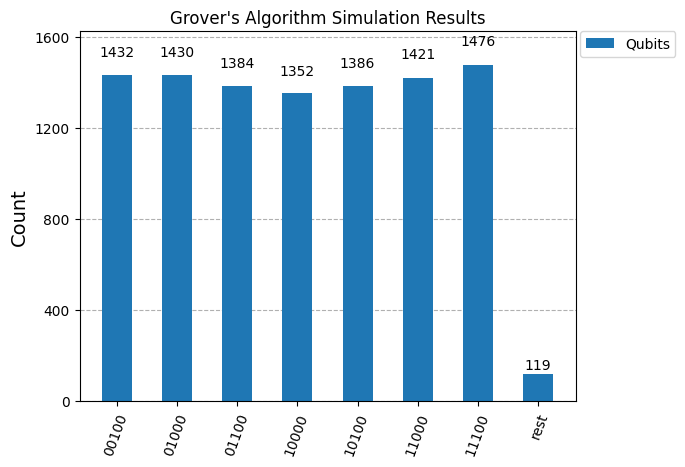

In [10]:
plot_histogram(
    data=results,
    legend=["Qubits"],
    number_to_keep=len(marked),
    title="Grover's Algorithm Simulation Results"
)

### Find b-smooth number

B-smooth numbers in range [1, 15] with B=2: [1, 2, 4, 8]
Total Search Space (N): 16
Number of Targets (M): 4
Optimal Iterations: 1

--- Search Results Analysis ---
Total Success Probability (Target found & x > 0): 100.00%
Frequency of '0000' (x=0): 0

Top Ranked Measurements:
Rank 1: Decimal  8 | Count: 2559 | Status: Valid
Rank 2: Decimal  4 | Count: 2527 | Status: Valid
Rank 3: Decimal  1 | Count: 2473 | Status: Valid
Rank 4: Decimal  2 | Count: 2441 | Status: Valid

Generating visualization...


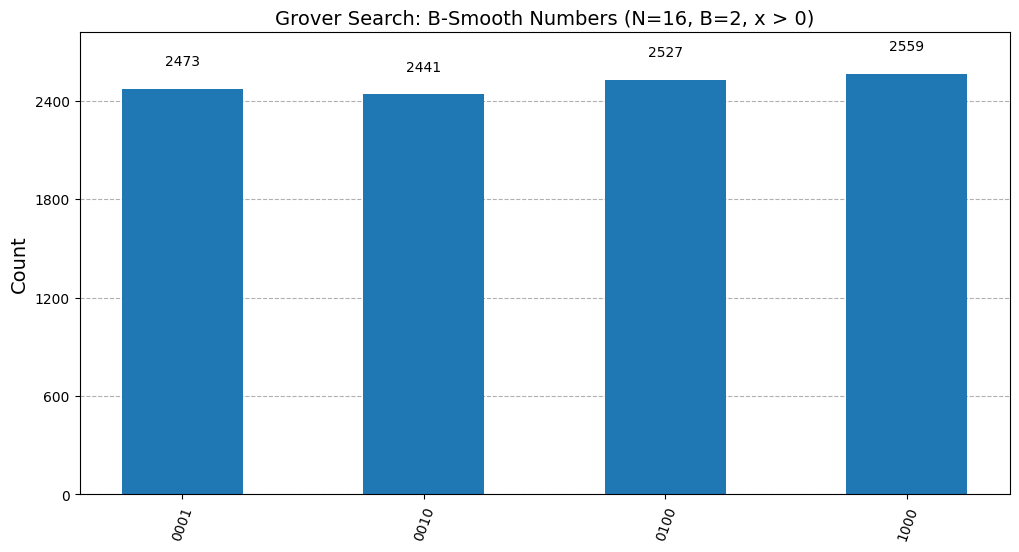

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from math import gcd, sqrt, pi
from heapq import nlargest

# --- 1. Tool Definitions ---

def is_b_smooth(n, b):
    """Check if n is b-smooth (Classical logic for Oracle identification)"""
    if n <= 1: return True 
    temp = n
    d = 2
    while d <= b:
        while temp % d == 0:
            temp //= d
        d += 1
    return temp == 1

def flip(target_bin, circuit, qubit="0"):
    """Flip '0' bits to '1' to apply the Multi-Controlled X gate"""
    for i, bit in enumerate(target_bin):
        if bit == qubit:
            circuit.x(i)

# --- 2. Quantum Circuit Components ---

def create_oracle(n_qubits, targets):
    """Phase marking Oracle (|a> -> -|a>) for multiple target states"""
    oracle_circuit = QuantumCircuit(n_qubits)
    for a in targets:
        bin_str = format(a, f"0{n_qubits}b")[::-1] # Qiskit bit ordering
        
        # Transformation: Map target state to |11...1>
        flip(bin_str, oracle_circuit, "0")
        
        # Apply Phase Flip (HXH = Z principle)
        oracle_circuit.h(n_qubits - 1)
        oracle_circuit.mcx(list(range(n_qubits - 1)), n_qubits - 1)
        oracle_circuit.h(n_qubits - 1)
        
        # Restore state
        flip(bin_str, oracle_circuit, "0")
        
    return oracle_circuit.to_gate(label="B-Smooth Oracle")

def create_diffuser(n_qubits):
    """Inversion about the mean (Grover Diffuser)"""
    diff_circuit = QuantumCircuit(n_qubits)
    diff_circuit.h(range(n_qubits))
    
    # Reflection about |0...0>
    zero_oracle = create_oracle(n_qubits, [0])
    diff_circuit.append(zero_oracle, range(n_qubits))
    
    diff_circuit.h(range(n_qubits))
    return diff_circuit.to_gate(label="Diffuser")

# --- 3. Main Configuration ---

n_qubits = 4
B_bound = 2          # B-smooth threshold (factors only include 2)
N_total = 2**n_qubits 

# Identify B-smooth numbers in range [1, 15], explicitly excluding 0
marked = [i for i in range(1, N_total) if is_b_smooth(i, B_bound)]
print(f"B-smooth numbers in range [1, {N_total-1}] with B={B_bound}: {marked}")

# Calculate optimal iterations: pi/4 * sqrt(N/M)
n_targets = len(marked)
iterations = int(pi/4 * sqrt(N_total / n_targets))

print(f"Total Search Space (N): {N_total}")
print(f"Number of Targets (M): {n_targets}")
print(f"Optimal Iterations: {iterations}")

# --- 4. Construct Grover Circuit ---

grover_circuit = QuantumCircuit(n_qubits)
grover_circuit.h(range(n_qubits)) # Initialize superposition

oracle_gate = create_oracle(n_qubits, marked)
diffuser_gate = create_diffuser(n_qubits)

for _ in range(iterations):
    grover_circuit.append(oracle_gate, range(n_qubits))
    grover_circuit.append(diffuser_gate, range(n_qubits))

grover_circuit.measure_all()

# --- 5. Simulation Execution ---

simulator = AerSimulator()
transpiled = transpile(grover_circuit, simulator)
result_obj = simulator.run(transpiled, shots=10000).result()
counts = result_obj.get_counts()

# --- 6. Analysis & Visualization ---

def show_results(results, marked_list):
    top_winners = nlargest(len(marked_list), results, key=results.get)
    
    print("\n--- Search Results Analysis ---")
    
    # Check success rate for all marked targets
    success_count = sum(results.get(format(m, f"0{n_qubits}b")[::-1], 0) for m in marked_list)
    print(f"Total Success Probability (Target found & x > 0): {success_count / 10000:.2%}")
    
    # Verify the state of '0000' (excluded value)
    zero_bin = format(0, f"0{n_qubits}b")[::-1]
    print(f"Frequency of '0000' (x=0): {results.get(zero_bin, 0)}")

    print("\nTop Ranked Measurements:")
    for i, k in enumerate(top_winners[:5]):
        val = int(k, 2)
        is_valid = is_b_smooth(val, B_bound) and val != 0
        status = "Valid" if is_valid else "Invalid"
        print(f"Rank {i+1}: Decimal {val:2d} | Count: {results[k]:4d} | Status: {status}")

show_results(counts, marked)

# Plot Results
print("\nGenerating visualization...")
fig, ax = plt.subplots(figsize=(12, 6))
plot_histogram(counts, ax=ax)
ax.set_title(f"Grover Search: B-Smooth Numbers (N=16, B={B_bound}, x > 0)", fontsize=14)
plt.show()

fig.savefig("find_b_smooth_3.pdf", bbox_inches="tight")